* Train a simple convnet on the MNIST dataset the first 5 digits [0-4].
* Freeze convolutional layers and fine-tune dense layers for the classification of digits [5-9].

## MNIST Dataset
The MNIST database contains 60,000 training images and 10,000 testing images taken from American Census Bureau employees and American high school students. The MNIST dataset is one of the most common datasets used for image classification and accessible from many different sources. In fact, even Tensorflow and Keras allow us to import and download the MNIST dataset directly from their API.

Let's import keras and load MNIST dataset

In [4]:
# Initialize the random number generator
import random
random.seed(0)

import warnings
warnings.filterwarnings("ignore")

In [5]:
from keras.backend import backend
from keras.datasets import mnist

# the data, shuffled and split between train and test sets
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11493376/11490434 [==============================] - 14s 1us/step


In [6]:
X_train.shape

(60000, 28, 28)

X_train and X_test contain greyscale RGB codes (from 0 to 255) while y_train and y_test contains labels from 0 to 9 which represents which number they actually are.

Let's visualize some numbers using matplotlib

Label: 0


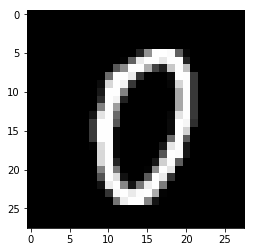

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline
print("Label: {}".format(y_train[1000]))
plt.imshow(X_train[1000], cmap='gray')

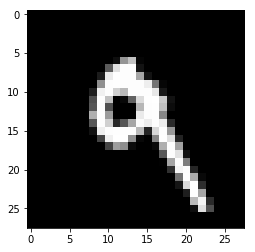

In [8]:
#This is for displaying the image
plt.imshow(X_test[7],cmap='gray')

In [9]:
#This is for checking the corresponding label of the image
y_test[7]

9

## Question 1

### Create two datasets
- First having digits from 0 to 4
- Second having digits from 5 to 9

Hint: use labels to separate data

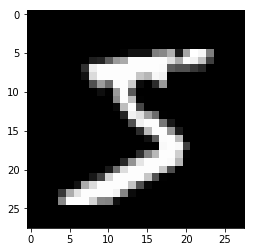

In [10]:
plt.imshow(X_train[0],cmap="gray")

## Question 2

### Print shape of the data
- print shape of all variables of both the datasets you created

## Question 3

### Reshape data
- reshape first dataset
- To be able to use the dataset in Keras, we need 4-dims numpy arrays. 
- reshape features to pass it to a Conv2D layer
- channel = 1
- reshape features of first dataset only
- do not reshape labels

In [11]:
import tensorflow as tf
#Converting the output to categorical variables:
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [8]:
#Building the graph to be used here:
tf.keras.backend.clear_session()
model=tf.keras.models.Sequential()

#Reshaping the data here:
model.add(tf.keras.layers.Reshape((28,28,1),input_shape=(28,28,)))

#Normalizing the data

model.add(tf.keras.layers.BatchNormalization())


In [9]:
#Applying the Convolutional Layers, Max Pooling 

In [10]:
#Adding the first convolutional layer
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3),activation="relu"))

#Adding the second convolutiona layer
model.add(tf.keras.layers.Conv2D(64,kernel_size=(3,3),activation="relu"))

#Adding the Maxpooling Layer

model.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))


W0917 17:25:29.173933 14812 deprecation.py:506] From C:\ProgramData\Anaconda3\lib\site-packages\tensorflow\python\ops\init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [11]:
#Adding more layers for classification

In [12]:
model.add(tf.keras.layers.Flatten())

In [13]:
#Dense layer
model.add(tf.keras.layers.Dense(128, activation='relu'))

#Add another dropout layer
model.add(tf.keras.layers.Dropout(0.25))

#Output layer
model.add(tf.keras.layers.Dense(10, activation='softmax'))

In [14]:
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', metrics=['accuracy'])

In [15]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape (Reshape)            (None, 28, 28, 1)         0         
_________________________________________________________________
batch_normalization (BatchNo (None, 28, 28, 1)         4         
_________________________________________________________________
conv2d (Conv2D)              (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 24, 24, 64)        18496     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 12, 12, 64)        0         
_________________________________________________________________
flatten (Flatten)            (None, 9216)              0         
_________________________________________________________________
dense (Dense)                (None, 128)               1

In [54]:
#Training the model now on the defined set of parameters

In [55]:
X_train.shape

(60000, 28, 28)

In [56]:
model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=10,batch_size=32)

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 92s 2ms/sample - loss: 0.1321 - acc: 0.9601 - val_loss: 0.0561 - val_acc: 0.9820
Epoch 2/10
60000/60000 [==============================] - 88s 1ms/sample - loss: 0.0495 - acc: 0.9845 - val_loss: 0.0363 - val_acc: 0.9880
Epoch 3/10
60000/60000 [==============================] - 90s 1ms/sample - loss: 0.0331 - acc: 0.9893 - val_loss: 0.0339 - val_acc: 0.9888
Epoch 4/10
60000/60000 [==============================] - 87s 1ms/sample - loss: 0.0244 - acc: 0.9923 - val_loss: 0.0391 - val_acc: 0.9893
Epoch 5/10
60000/60000 [==============================] - 82s 1ms/sample - loss: 0.0196 - acc: 0.9940 - val_loss: 0.0278 - val_acc: 0.9908
Epoch 6/10
60000/60000 [==============================] - 85s 1ms/sample - loss: 0.0148 - acc: 0.9951 - val_loss: 0.0333 - val_acc: 0.9906
Epoch 7/10
60000/60000 [==============================] - 82s 1ms/sample - loss: 0.0121 - acc: 0.9962 - val_loss: 0.

## Question 4

### Normalize data
- normalize first dataset
- we must normalize our data as it is always required in neural network models
- we can achieve this by dividing the RGB codes to 255 (which is the maximum RGB code minus the minimum RGB code)
- normalize X_train and X_test
- make sure that the values are float so that we can get decimal points after division

In [0]:
#Done above

### Print shape of data and number of images
- for first dataset
- print shape of X_train
- print number of images in X_train
- print number of images in X_test

In [0]:
#Done above

## Question 5

### One-hot encode the class vector
- encode labels of first dataset
- convert class vectors (integers) to binary class matrix
- convert y_train and y_test
- number of classes: 5
- we are doing this to use categorical_crossentropy as loss

Hint: you can use keras.utils.to_categorical

In [0]:
#Done above

## Question 6
We will build our model by using high level Keras.

### Initialize a sequential model
- define a sequential model
- add 2 convolutional layers
    - no of filters: 32
    - kernel size: 3x3
    - activation: "relu"
    - input shape: (28, 28, 1) for first layer
- add a max pooling layer of size 2x2
- add a dropout layer
    - dropout layers fight with the overfitting by disregarding some of the neurons while training
    - use dropout rate 0.2

In [0]:
#Done above

## Question 7

### Add classification layers
- do this after doing question 6
- flatten the data
    - add Flatten later
    - flatten layers flatten 2D arrays to 1D array before building the fully connected layers
- add 2 dense layers
    - number of neurons in first layer: 128
    - number of neurons in last layer: number of classes
    - activation function in first layer: relu
    - activation function in last layer: softmax
    - we may experiment with any number of neurons for the first Dense layer; however, the final Dense layer must have neurons equal to the number of output classes
- you can add a dropout layer in between, if necessary

In [0]:
#Done above

## Question 8

### Compile and fit the model
- compile your model
    - loss: "categorical_crossentropy"
    - metrics: "accuracy"
    - optimizer: "sgd"
- fit your model
    - give train data - features and labels
    - batch size: 128
    - epochs: 10
    - give validation data - features and labels

In [0]:
#Done above

## Question 9

### Evaluate model
- evaluate your model and get accuracy
- use test features and labels

In [0]:
#Done above

## Question 10

## Transfer learning
Now we will apply this model on second dataset (5-9 digits)

- fix the first convolution layers so that the weights in the convolution layers dont get updated in the process of training
- get the second dataset
- train the last 2 dense layers
- predict the accuracy and loss

# Make only dense layers trainable
- set trainalble = False for all layers other than Dense layers

In [16]:
img_size=224
img_depth=3

In [17]:
X_train[0].shape

(28, 28)

In [12]:
#Importing the ResNet50 model
from keras.applications.resnet50 import ResNet50, preprocess_input

#Loading the ResNet50 model with pre-trained ImageNet weights
model = ResNet50(weights='imagenet', include_top=False, input_shape=(200, 200, 3))

In [13]:
from scipy.misc import imresize

In [14]:
X_train.shape

(60000, 28, 28)

In [15]:
#Reshaping the training data

In [17]:
import numpy as np
#Reshaping the training data
X_train_new = np.array([imresize(X_train[i], (200, 200, 3,1)) for i in range(0, len(X_train))]).astype('float32')

In [18]:
X_train_new.shape

(60000, 200, 200)

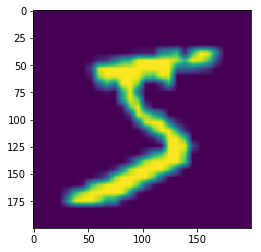

In [19]:
plt.imshow(X_train_new[0])

In [20]:
#Preprocessing the data, so that it can be fed to the pre-trained ResNet50 model. 
resnet_train_input = preprocess_input(X_train_new)

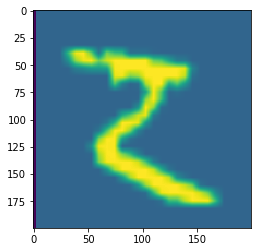

In [21]:
plt.imshow(resnet_train_input[0])

In [22]:
from keras.applications.resnet50 import ResNet50, preprocess_input
#Creating bottleneck features for the training data
train_features = model.predict(resnet_train_input)#Saving the bottleneck features
#np.savez('resnet_features_train', features=train_features)

ValueError: Error when checking input: expected input_2 to have 4 dimensions, but got array with shape (60000, 200, 200)

In [32]:
#sequential model with newly added fully connected layers that match the number of classes in the Cifar-10 dataset
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D
from keras.layers import Dropout, Flatten, GlobalAveragePooling2D
model = Sequential()
model.add(GlobalAveragePooling2D(input_shape=train_features.shape[1:]))
model.add(Dropout(0.3))
model.add(Dense(10, activation='softmax'))
model.summary()

NameError: name 'train_features' is not defined

### Reshape data
- reshape second dataset
- To be able to use the dataset in Keras, we need 4-dims numpy arrays. 
- reshape features to pass it to a Conv2D layer
- channel = 1
- reshape features of first dataset only
- do not reshape labels

In [19]:
model.summary()

Model: "resnet50"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
conv1_pad (ZeroPadding2D)       (None, 230, 230, 3)  0           input_1[0][0]                    
__________________________________________________________________________________________________
conv1 (Conv2D)                  (None, 112, 112, 64) 9472        conv1_pad[0][0]                  
__________________________________________________________________________________________________
bn_conv1 (BatchNormalization)   (None, 112, 112, 64) 256         conv1[0][0]                      
___________________________________________________________________________________________

In [20]:
model.output

<tf.Tensor 'activation_48/Relu:0' shape=(?, 7, 7, 2048) dtype=float32>

In [95]:
#Setting some trainable layer to be non-trainable

In [21]:
#Set pre-trained model layers to not trainable
for layer in model.layers:
    layer.trainable = False

In [107]:
#Building the graph to be used here:
#tf.keras.backend.clear_session()
#model=tf.keras.models.Sequential()

#Reshaping the data here:
#model.add(tf.keras.layers.Reshape((28,28,1),input_shape=(28,28,)))

#Normalizing the data

#model.add(tf.keras.layers.BatchNormalization())

In [22]:
#get Output layer of Pre0trained model
x = model.output
print(x)

#Flatten the output to feed to Dense layer
x = tf.keras.layers.Flatten()(x)

#Add one Dense layer
x = tf.keras.layers.Dense(200, activation='relu')(x)

#Add output layer
prediction = tf.keras.layers.Dense(9,activation='softmax')(x)

Tensor("activation_48/Relu:0", shape=(?, 7, 7, 2048), dtype=float32)


In [23]:
#Building final model for validation

In [24]:
#Using Keras Model class
final_model = tf.keras.models.Model(inputs=model.input, #Pre-trained model input as input layer
                                    outputs=prediction) #Output layer added

In [25]:
final_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [26]:
final_model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
conv1_pad (ZeroPadding2D)       (None, 230, 230, 3)  0           input_1[0][0]                    
__________________________________________________________________________________________________
conv1 (Conv2D)                  (None, 112, 112, 64) 9472        conv1_pad[0][0]                  
__________________________________________________________________________________________________
bn_conv1 (BatchNormalization)   (None, 112, 112, 64) 256         conv1[0][0]                      
______________________________________________________________________________________________

In [28]:
#Training the model


In [27]:
final_model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=10,batch_size=32)

ValueError: Error when checking input: expected input_1 to have 4 dimensions, but got array with shape (60000, 28, 28)

### Normalize data
- normalize second data
- we must normalize our data as it is always required in neural network models
- we can achieve this by dividing the RGB codes to 255 (which is the maximum RGB code minus the minimum RGB code)
- normalize X_train and X_test
- make sure that the values are float so that we can get decimal points after division

### Print shape of data and number of images
- print shape of X_train
- print number of images in X_train
- print number of images in X_test

### One-hot encode the class vector
- convert class vectors (integers) to binary class matrix
- convert y_train and y_test
- number of classes: 5
- we are doing this to use categorical_crossentropy as loss

Hint: you can use keras.utils.to_categorical

### Fit the model
- give train data - features and labels
- batch size: 128
- epochs: 10
- give validation data - features and labels

### Evaluate model
- evaluate your model and get accuracy
- use test features and labels

-----------------------------------------------------------------------------

# Sentiment analysis 

The objective of the second problem is to perform Sentiment analysis from the tweets collected from the users targeted at various mobile devices.
Based on the tweet posted by a user (text), we will classify if the sentiment of the user targeted at a particular mobile device is positive or not.

## Question 1

### Read the data
- read tweets.csv
- use latin encoding if it gives encoding error while loading

In [212]:
#There is this specific encoding which needs to be applied on the data so as it will be importing this file
import pandas as pd
#df.encode('utf-8').strip()
df=pd.read_csv("tweets.csv",encoding='ISO-8859-1')


In [213]:
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


### Drop null values
- drop all the rows with null values

In [214]:
#Checking how many are the number of null values that we see in the data
df.isna().sum()
#We see that there are a lot of null values and in the next step we are going to drop these values

tweet_text                                               1
emotion_in_tweet_is_directed_at                       5802
is_there_an_emotion_directed_at_a_brand_or_product       0
dtype: int64

In [215]:
df.shape

(9093, 3)

In [216]:
df=df.dropna()

In [217]:
df.shape

(3291, 3)

### Print the dataframe
- print initial 5 rows of the data
- use df.head()

In [218]:
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


## Question 2

### Preprocess data
- convert all text to lowercase - use .lower()
- select only numbers, alphabets, and #+_ from text - use re.sub()
- strip all the text - use .strip()
    - this is for removing extra spaces

In [219]:
#Converting all the text into lowercase

In [220]:
#This step is taken for the data to be converted into str format and then do a lower case on that
df["tweet_text"]=df["tweet_text"].str.lower()

In [221]:
df["is_there_an_emotion_directed_at_a_brand_or_product"]=df["is_there_an_emotion_directed_at_a_brand_or_product"].str.lower()

In [222]:
df["emotion_in_tweet_is_directed_at"]=df["emotion_in_tweet_is_directed_at"].str.lower()

In [223]:
df.head(n=1)

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 i have a 3g iphone. after 3 hrs twe...,iphone,negative emotion


In [224]:
df[["tweet_text"]].head(n=1)

,tweet_text
0,.@wesley83 i have a 3g iphone. after 3 hrs twe...


In [225]:
len(df["tweet_text"])

3291

In [226]:
df["tweet_text"]=df["tweet_text"].str.replace("?","",regex=True)

In [227]:
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 i have a 3g iphone. after 3 hrs twe...,iphone,negative emotion
1,@jessedee know about @fludapp awesome ipad/ip...,ipad or iphone app,positive emotion
2,@swonderlin can not wait for #ipad 2 also. the...,ipad,positive emotion
3,@sxsw i hope this year's festival isn't as cra...,ipad or iphone app,negative emotion
4,@sxtxstate great stuff on fri #sxsw: marissa m...,google,positive emotion


In [228]:
#re.sub("@","",list)

In [229]:
df["tweet_text"]=df["tweet_text"].str.replace("@","",regex=True)

In [230]:
df["tweet_text"]=df["tweet_text"].str.replace(".","",regex=True)

In [231]:
df["tweet_text"]=df["tweet_text"].str.replace("//","",regex=True)

In [232]:
df["tweet_text"]=df["tweet_text"].str.replace("!","",regex=True)

In [233]:
df["tweet_text"]=df["tweet_text"].str.replace("+","",regex=True)

In [234]:
df["tweet_text"]=df["tweet_text"].str.replace(":","",regex=True)

In [235]:
df["tweet_text"]=df["tweet_text"].str.strip()

print dataframe

In [236]:
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,wesley83 i have a 3g iphone after 3 hrs tweeti...,iphone,negative emotion
1,jessedee know about fludapp awesome ipad/ipho...,ipad or iphone app,positive emotion
2,swonderlin can not wait for #ipad 2 also they ...,ipad,positive emotion
3,sxsw i hope this year's festival isn't as cras...,ipad or iphone app,negative emotion
4,sxtxstate great stuff on fri #sxsw marissa may...,google,positive emotion


## Question 3

# Preprocess data
- in column "is_there_an_emotion_directed_at_a_brand_or_product"
    - select only those rows where value equal to "positive emotion" or "negative emotion"
- find the value counts of "positive emotion" and "negative emotion"

In [237]:
df=df[(df.iloc[:,2]=="positive emotion")|(df.iloc[:,2]=="negative emotion")]

In [238]:
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,wesley83 i have a 3g iphone after 3 hrs tweeti...,iphone,negative emotion
1,jessedee know about fludapp awesome ipad/ipho...,ipad or iphone app,positive emotion
2,swonderlin can not wait for #ipad 2 also they ...,ipad,positive emotion
3,sxsw i hope this year's festival isn't as cras...,ipad or iphone app,negative emotion
4,sxtxstate great stuff on fri #sxsw marissa may...,google,positive emotion


In [239]:
df.is_there_an_emotion_directed_at_a_brand_or_product.value_counts()
#We can see that there are more of positive emotions than the negative emotions
#which means that we have an imbalanced dataset, the null accuracy is 83% in this case

positive emotion    2672
negative emotion     519
Name: is_there_an_emotion_directed_at_a_brand_or_product, dtype: int64

## Question 4

### Encode labels
- in column "is_there_an_emotion_directed_at_a_brand_or_product"
    - change "positive emotion" to 1
    - change "negative emotion" to 0
- use map function to replace values

In [240]:
df.head(n=1)

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,wesley83 i have a 3g iphone after 3 hrs tweeti...,iphone,negative emotion


In [241]:
#Encoding the labels manually 
df['is_there_an_emotion_directed_at_a_brand_or_product'] = df['is_there_an_emotion_directed_at_a_brand_or_product'].apply(lambda x: 0 if x == "negative emotion" else 1)

## Question 5

### Get feature and label
- get column "tweet_text" as feature
- get column "is_there_an_emotion_directed_at_a_brand_or_product" as label

In [242]:
df.head(n=2)

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,wesley83 i have a 3g iphone after 3 hrs tweeti...,iphone,0
1,jessedee know about fludapp awesome ipad/ipho...,ipad or iphone app,1


In [243]:
x_ind=df["tweet_text"]
y_dep=df["is_there_an_emotion_directed_at_a_brand_or_product"]

### Create train and test data
- use train_test_split to get train and test set
- set a random_state
- test_size: 0.25

In [244]:
from sklearn.model_selection import train_test_split


In [245]:
X_train,X_test,y_train,y_test=train_test_split(x_ind,y_dep,test_size=0.25)

In [246]:
X_train.shape

(2393,)

In [247]:
X_test.shape

(798,)

In [248]:
y_train.shape

(2393,)

In [249]:
y_test.shape

(798,)

# Question 6

### Vectorize data
- create document-term matrix
- use CountVectorizer()
    - ngram_range: (1, 2)
    - stop_words: 'english'
    - min_df: 2   
- do fit_transform on X_train
- do transform on X_test

In [259]:
# use CountVectorizer to create document-term matrices from X_train and X_test
import scipy as sp
from sklearn.cross_validation import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from textblob import TextBlob, Word
from nltk.stem.snowball import SnowballStemmer
%matplotlib inline

#Creating the document term matrix for this one:

vect = CountVectorizer(ngram_range=(1,2),stop_words="english",min_df=2)
X_train_dtm=vect.fit_transform(X_train)
X_test_dtm=vect.transform(X_test)

In [206]:
#list of text documents
#text = ["The quick brown fox jumped over the lazy dog."]
# create the transform
#vectorizer = CountVectorizer()
# tokenize and build vocab
#vectorizer.fit(text)
#print(vectorizer.vocabulary_)
#vector = vectorizer.transform(text)
# summarize encoded vector
#print(vector.shape)
#print(type(vector))
#print(vector.toarray())

{'the': 7, 'quick': 6, 'brown': 0, 'fox': 2, 'jumped': 3, 'over': 5, 'lazy': 4, 'dog': 1}
(1, 8)
<class 'scipy.sparse.csr.csr_matrix'>


## Question 7

### Select classifier logistic regression
- use logistic regression for predicting sentiment of the given tweet
- initialize classifier

In [260]:
logreg=LogisticRegression()

In [261]:
X_train_dtm

<2393x5249 sparse matrix of type '<class 'numpy.int64'>'
	with 37896 stored elements in Compressed Sparse Row format>

In [262]:
logreg.fit(X_train_dtm,y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1,
          penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
          verbose=0, warm_start=False)

In [263]:
y_pred_class = logreg.predict(X_test_dtm)

In [264]:
from sklearn import metrics
print(metrics.accuracy_score(y_test, y_pred_class))
#So we are getting 87% accuracy on the test data with this n gram range

0.8609022556390977


### Fit the classifer
- fit logistic regression classifier

In [0]:
#Fitted above the Logistic Regresssion

## Question 8

### Select classifier naive bayes
- use naive bayes for predicting sentiment of the given tweet
- initialize classifier
- use MultinomialNB

In [265]:
mnb=MultinomialNB()

In [266]:
mnb.fit(X_train_dtm,y_train)

MultinomialNB(alpha=1.0, class_prior=None, fit_prior=True)

In [268]:
y_pred_class = mnb.predict(X_test_dtm)

In [269]:
from sklearn import metrics
print(metrics.accuracy_score(y_test, y_pred_class))
#So we are getting 85% accuracy on the test data with this n gram range and Multinomial NB

0.8558897243107769


### Fit the classifer
- fit naive bayes classifier

In [0]:
#Done in the previous step

## Question 9

### Make predictions on logistic regression
- use your trained logistic regression model to make predictions on X_test

In [0]:
#Done already 

### Make predictions on naive bayes
- use your trained naive bayes model to make predictions on X_test
- use a different variable name to store predictions so that they are kept separately

In [0]:
#Done above

## Question 10

### Calculate accuracy of logistic regression
- check accuracy of logistic regression classifer
- use sklearn.metrics.accuracy_score

In [0]:
#Done already 

### Calculate accuracy of naive bayes
- check accuracy of naive bayes classifer
- use sklearn.metrics.accuracy_score

In [270]:
#Done already,
#Logistic Regression is performing better than the multinomial NB